In [24]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import ast
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_final = pd.read_csv('final_df.csv')

In [3]:
df_final.head()

,name,type,gender,area_name,genre_label,album_count,years_active_pro,label_count,tag_count,release_rel_count
0,10cc,Group,Not applicable,United Kingdom,"['rock', 'pop']",12,54.0,1,15,13
1,2 Chainz,Person,Male,North America,['hip hop'],19,32.0,5,7,4
2,2 Mello,Person,Male,North America,['hip hop'],15,31.0,1,6,5
3,2 Unlimited,Group,Not applicable,Europe (Excl. UK),"['hip hop', 'electronic']",4,35.0,0,14,0
4,2Pac,Person,Male,North America,['hip hop'],11,7.0,0,9,0


In [10]:
df_final['genre_label'] = df_final['genre_label'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

mlb = MultiLabelBinarizer()

genre_matrix = mlb.fit_transform(df_final['genre_label'])

genre_cols = [f'is_{c.replace(" ", "_").lower()}' for c in mlb.classes_]
df_genres = pd.DataFrame(genre_matrix, columns=genre_cols, index=df_final.index)

df_model = pd.concat([df_final, df_genres], axis=1)

print(df_genres.columns.tolist())

['is_electronic', 'is_hip_hop', 'is_jazz', 'is_pop', 'is_rock']


In [11]:
df_model.head()

,name,type,gender,area_name,genre_label,album_count,years_active_pro,label_count,tag_count,release_rel_count,is_electronic,is_hip_hop,is_jazz,is_pop,is_rock
0,10cc,Group,Not applicable,United Kingdom,"[rock, pop]",12,54.0,1,15,13,0,0,0,1,1
1,2 Chainz,Person,Male,North America,[hip hop],19,32.0,5,7,4,0,1,0,0,0
2,2 Mello,Person,Male,North America,[hip hop],15,31.0,1,6,5,0,1,0,0,0
3,2 Unlimited,Group,Not applicable,Europe (Excl. UK),"[hip hop, electronic]",4,35.0,0,14,0,1,1,0,0,0
4,2Pac,Person,Male,North America,[hip hop],11,7.0,0,9,0,0,1,0,0,0


In [12]:
df_cats = pd.get_dummies(df_model[['type', 'gender', 'area_name']], drop_first=True)

X = pd.concat([
    df_model[['years_active_pro', 'label_count', 'tag_count', 'release_rel_count']],
    df_genres,
    df_cats
], axis = 1)

y = df_model['album_count']

artist_names = df_model['name']

X.head()

,years_active_pro,label_count,tag_count,release_rel_count,is_electronic,is_hip_hop,is_jazz,is_pop,is_rock,type_Person,gender_Male,gender_Not applicable,area_name_North America,area_name_Rest of World,area_name_United Kingdom
0,54.0,1,15,13,0,0,0,1,1,False,False,True,False,False,True
1,32.0,5,7,4,0,1,0,0,0,True,True,False,True,False,False
2,31.0,1,6,5,0,1,0,0,0,True,True,False,True,False,False
3,35.0,0,14,0,1,1,0,0,0,False,False,True,False,False,False
4,7.0,0,9,0,0,1,0,0,0,True,True,False,True,False,False


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_trian shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_trian shape: (1189, 15)
X_test shape: (298, 15)


In [16]:
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [17]:
y_pred = xgb_model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [21]:
print("-" * 30)
print("XGBOOST SCORES:")
print(f"MAE: {mae:.2f} album")
print(f"RMSE: {rmse:.2f} album")
print(f"R^2: {r2:.2f}")

------------------------------
XGBOOST SCORES:
MAE: 5.62 album
RMSE: 7.29 album
R^2: 0.16


# Feature Importance

In [26]:
importances = xgb_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

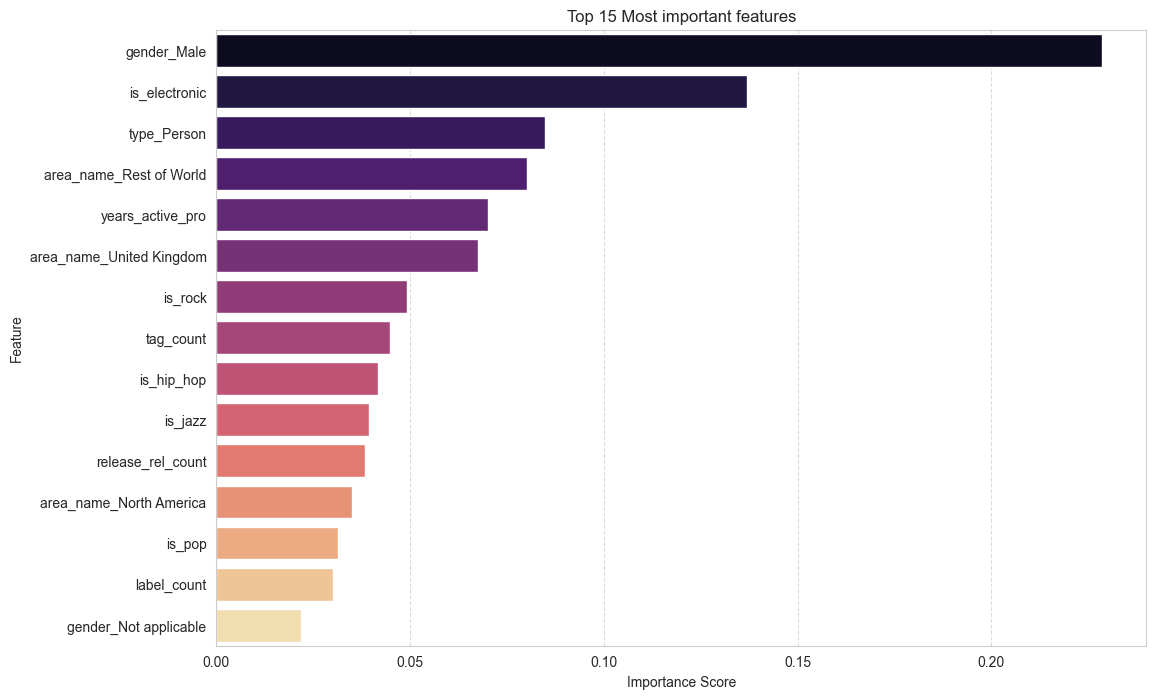

In [27]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma', hue = 'Feature', legend = False)
plt.title('Top 15 Most important features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()